In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from statsmodels.stats.stattools import durbin_watson


In [2]:
cars = sns.load_dataset('mpg').dropna() # There are some rows with missing horsepower values , we drop them for convenience

In [3]:
cars.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [4]:
# We will do all the test we ever do on a dataset to enure the linear model can make statistically confident predictions.

# 1) Multicollinearity Test 


KeyboardInterrupt: 

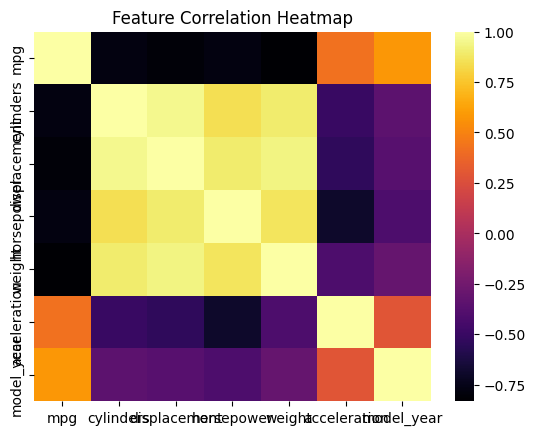

In [5]:
# We will first plot the heatmap of the features to look for any redundant cols correlating to each other and causing multicollinearity.
plt.title('Feature Correlation Heatmap')
sns.heatmap(cars.drop(columns=['name','origin']).corr(),annot=True,cmap='inferno')
plt.show()

In [ ]:
# A complete mess of correlated features

In [ ]:
# Then we also do VIF test to see how each variable can or cannot be predicted by every other variables 
# Ranges from 0 - 5 can be tolerated , till or above ten means there is a huge correlation between this feature and other cols
# The actual range is from 1 - inf


# 1. Prepare your data (Separate your target variable)
# Replace 'target_column' with the actual name of your Y variable
X = cars.drop(columns=['name','origin']) 

# 2. Add a constant intercept (Crucial: VIF requires an intercept to be accurate)
X_with_const = add_constant(X)

# 3. Calculate VIF for each feature using a list comprehension
vif_data = pd.DataFrame()
vif_data["features"] = X_with_const.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_with_const.values, i) 
    for i in range(X_with_const.shape[1])
]

# 4. Clean up the output
# Remove the constant row and sort by highest VIF
vif_data = vif_data[vif_data["features"] != 'const']
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

print(vif_data)


       features        VIF
0  displacement  19.697244
1        weight  13.598221
2     cylinders  10.660295
3    horsepower   9.398062
4           mpg   5.242609
5  acceleration   2.630344
6    model_year   1.907643


In [ ]:
# As you can see these top features are heavily correlated and a specific measure for this need to be decided asap because
# if not it will affect model performance.

# Some possible methods include : 

#       Dropping values with high VIF or cols with redundant information
#       Use Regularized Regression 
#       Opt other strategy

In [ ]:
# In here make sure to consider the fact that the target column will have a high VIF value and in heatmap 
# So make sure that we do not drop the target column itself !!!
# Also for this analysis we tend to drop the target column itself before doing any analysis

In [ ]:
# For other tests we will be using a different dataset which would be simple in nature and we will use a simple linear-regressor for this to 
# produce residuals and then analyze it.

# 2) Independence of Errors

In [ ]:
# For this test what we are trying to make sure our assumption is correct on residuals.
# Now what we did while deriving the Minimizing function we assumped that every residual point must be independent of each other.
# This is because when we calculate the likelihood for the errors we tend to take the product of the errors when deriving the MSE function.

# To check whether this was followed or not we have : 
""" 
Diagnostic Test #2 —
     Durbin-Watson test (statistic roughly 0–4; near 2 = no autocorrelation, 
     pushed toward 0 or 4 = strong positive/negative autocorrelation), 
     plus a visual check: plot residuals in collection order (e.g., by day).
             Short streaks of same-signed residuals happen by pure chance even under true independence 
             (like getting heads 3 times in a row on a fair coin) — the real signal is sustained, 
             extended runs far longer/more frequent than randomness would produce (e.g., 15 days positive, then 20 days negative, in a slow wave), 
             not the occasional short streak.
"""

' \nDiagnostic Test #2 —\n     Durbin-Watson test (statistic roughly 0–4; near 2 = no autocorrelation, \n     pushed toward 0 or 4 = strong positive/negative autocorrelation), \n     plus a visual check: plot residuals in collection order (e.g., by day).\n             Short streaks of same-signed residuals happen by pure chance even under true independence \n             (like getting heads 3 times in a row on a fair coin) — the real signal is sustained, \n             extended runs far longer/more frequent than randomness would produce (e.g., 15 days positive, then 20 days negative, in a slow wave), \n             not the occasional short streak.\n'

In [7]:
# For this I will use a simple dataset of only one X col and another as y
students = pd.read_csv(Path.cwd().parent / "datasets"/ 'L1.csv')

In [8]:
students.head()

,SAT,GPA
0,1714,2.40
1,1664,2.52
2,1760,2.54
3,1685,2.74
4,1693,2.83


In [10]:
X_train,X_test,y_train,y_test = train_test_split(
                                                    students[['SAT']],students['GPA'],
                                                    test_size=0.2,
                                                    random_state=40
)

In [11]:
# We fit using a simple Linear Model
model = LinearRegression()

model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
# Make predictions and calculate residuals
y_pred = model.predict(X_test)

residuals = y_test - y_pred

In [13]:
# Now pass this to durbin watson test
dw_value = durbin_watson(residuals) # Target value is ~2.0

In [15]:
dw_value # Our values is near 2

np.float64(2.1451849686378583)

In [16]:
# What does this even mean ?
#   This means that there is almost no correlation between the residuals
#   We aim for values near 2 and when values tend to 0 and 4 , then it signals residuals being dependent on each other (correlation)